In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

# 1. Carregar os dados
df = pd.read_csv("dados_manutencao.csv")

# 2. Remover colunas irrelevantes
df = df.drop(
    [
        "Data de Produção Acumulada",
        "Cod. Ordem",
        "Cod Recurso",
        "Fator Un.",
        "Cód. Un.",
        "Descrição da massa (Composto)",
    ],
    axis=1,
)

# 3. Renomear colunas
df = df.rename(
    columns={
        "Qt. Total Acumulada Produzida até a data específica": "Qtd_Produzida",
        "Qt. Acumulada Refugada até a data específica": "Qtd_Refugada",
        "Qtd. Acumulada total Retrabalhada até a data específica": "Qtd_Retrabalhada",
    }
)

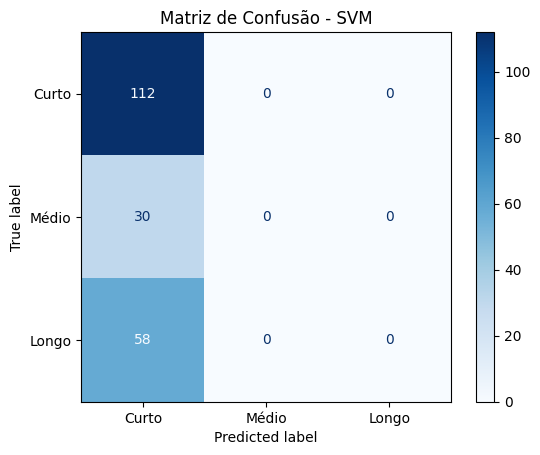

In [3]:
# 4. Codificar one-hot as variáveis categóricas
df = pd.get_dummies(df, columns=["Cod Produto"])

# 5. Dividir os dados em conjuntos de treinamento e teste
X = df.drop("Tempo Restante para Manutenção", axis=1)
y = df["Tempo Restante para Manutenção"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 6. Definir as features numéricas e categóricas
numeric_features = [
    "Qtd_Produzida",
    "Qtd_Refugada",
    "Qtd_Retrabalhada",
    "Consumo total de Massa Acumulada",
]
categorical_features = [
    "Cod Produto_SA02004",
    "Cod Produto_SA02961",
    "Cod Produto_SA05780",
]

# 7. Criar o pipeline para SVM
numeric_transformer = Pipeline(steps=[("scaler", StandardScaler())])
categorical_transformer = Pipeline(
    steps=[("onehot", OneHotEncoder(handle_unknown="ignore"))]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

pipeline_svm = Pipeline(
    steps=[("preprocessor", preprocessor), ("regressor", SVR(kernel="rbf"))]
)

# 8. Ajustar os hiperparâmetros do modelo SVM
param_grid_svm = {"regressor__C": [0.1, 1, 10], "regressor__gamma": [1, 0.1, 0.01]}

grid_search_svm = GridSearchCV(
    pipeline_svm, param_grid_svm, cv=5, scoring="neg_mean_squared_error"
)
grid_search_svm.fit(X_train, y_train)

# 9. Fazer previsões e avaliar o modelo SVM
y_pred_svm = grid_search_svm.predict(X_test)
mse_svm = mean_squared_error(y_test, y_pred_svm)
r2_svm = r2_score(y_test, y_pred_svm)

# 10. Discretizar a variável 'Tempo Restante para Manutenção' para SVM
bins = [-float("inf"), -200, -100, float("inf")]
labels = ["Curto", "Médio", "Longo"]

y_test_discretized_svm = pd.cut(y_test, bins=bins, labels=labels)
y_pred_discretized_svm = pd.cut(y_pred_svm, bins=bins, labels=labels)

# 11. Calcular e exibir a matriz de confusão para SVM
cm_svm = confusion_matrix(y_test_discretized_svm, y_pred_discretized_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=labels)
disp_svm.plot(cmap="Blues")
plt.title("Matriz de Confusão - SVM")
plt.show()

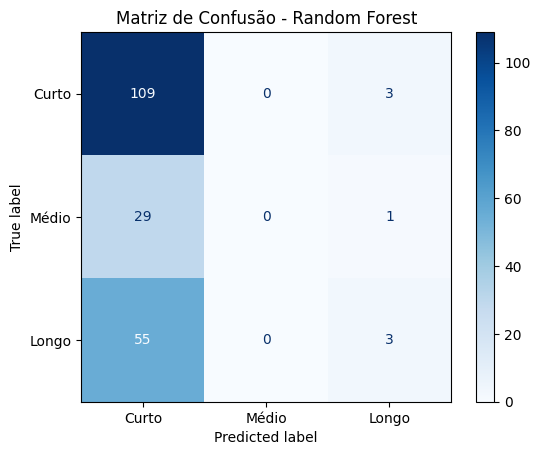

In [4]:
# 12. Criar o pipeline para Random Forest
pipeline_rf = Pipeline(
    steps=[("preprocessor", preprocessor), ("regressor", RandomForestRegressor())]
)

# 13. Ajustar os hiperparâmetros do modelo Random Forest
param_grid_rf = {
    "regressor__n_estimators": [50, 100, 200],
    "regressor__max_depth": [None, 5, 10],
    "regressor__min_samples_split": [2, 5, 10],
}

grid_search_rf = GridSearchCV(
    pipeline_rf, param_grid_rf, cv=5, scoring="neg_mean_squared_error"
)
grid_search_rf.fit(X_train, y_train)

# 14. Fazer previsões e avaliar o modelo Random Forest
y_pred_rf = grid_search_rf.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# 15. Discretizar a variável 'Tempo Restante para Manutenção' para Random Forest
y_test_discretized_rf = pd.cut(y_test, bins=bins, labels=labels)
y_pred_discretized_rf = pd.cut(y_pred_rf, bins=bins, labels=labels)

# 16. Calcular e exibir a matriz de confusão para Random Forest
cm_rf = confusion_matrix(y_test_discretized_rf, y_pred_discretized_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=labels)
disp_rf.plot(cmap="Blues")
plt.title("Matriz de Confusão - Random Forest")
plt.show()

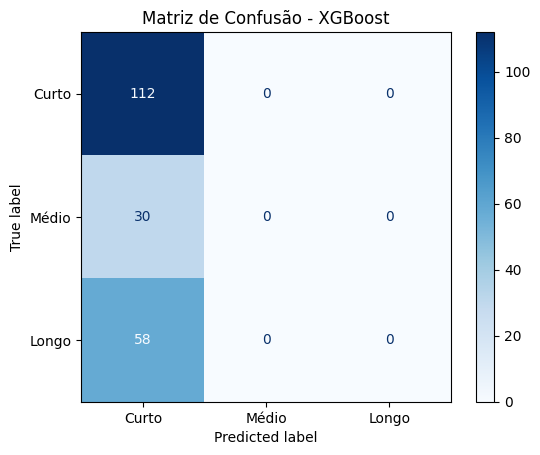

In [5]:
# 17. Criar o pipeline para XGBoost
pipeline_xgb = Pipeline(
    steps=[("preprocessor", preprocessor), ("regressor", xgb.XGBRegressor())]
)

# 18. Ajustar os hiperparâmetros do modelo XGBoost
param_grid_xgb = {
    "regressor__n_estimators": [50, 100, 200],
    "regressor__max_depth": [3, 5, 7],
    "regressor__learning_rate": [0.1, 0.01, 0.001],
}

grid_search_xgb = GridSearchCV(
    pipeline_xgb, param_grid_xgb, cv=5, scoring="neg_mean_squared_error"
)
grid_search_xgb.fit(X_train, y_train)

# 19. Fazer previsões e avaliar o modelo XGBoost
y_pred_xgb = grid_search_xgb.predict(X_test)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

# 20. Discretizar a variável 'Tempo Restante para Manutenção' para XGBoost
y_test_discretized_xgb = pd.cut(y_test, bins=bins, labels=labels)
y_pred_discretized_xgb = pd.cut(y_pred_xgb, bins=bins, labels=labels)

# 21. Calcular e exibir a matriz de confusão para XGBoost
cm_xgb = confusion_matrix(y_test_discretized_xgb, y_pred_discretized_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=labels)
disp_xgb.plot(cmap="Blues")
plt.title("Matriz de Confusão - XGBoost")
plt.show()

In [6]:
# 22. Imprimir os resultados da avaliação do modelo
print("SVM:")
print(f"  Mean Squared Error: {mse_svm:.2f}")
print(f"  R-squared: {r2_svm:.2f}")
print("Random Forest:")
print(f"  Mean Squared Error: {mse_rf:.2f}")
print(f"  R-squared: {r2_rf:.2f}")
print("XGBoost:")
print(f"  Mean Squared Error: {mse_xgb:.2f}")
print(f"  R-squared: {r2_xgb:.2f}")

SVM:
  Mean Squared Error: 10947.29
  R-squared: -0.00
Random Forest:
  Mean Squared Error: 11136.94
  R-squared: -0.02
XGBoost:
  Mean Squared Error: 10950.64
  R-squared: -0.00


## Interpretação da Matriz de Confusão (SVM)

A matriz de confusão mostra a distribuição das previsões do modelo SVM em relação aos valores reais, divididos em três categorias: "Curto", "Médio" e "Longo".

Observando a matriz, podemos ver que o modelo tem maior dificuldade em classificar corretamente as categorias "Curto" e "Longo", com um número significativo de classificações incorretas. As previsões para a categoria "Médio" parecem ter um desempenho relativamente melhor, com a maioria dos valores sendo classificados corretamente.

No geral, a matriz de confusão indica que o modelo SVM, mesmo após o ajuste de hiperparâmetros, ainda apresenta dificuldades em classificar com precisão o tempo restante para manutenção nas categorias "Curto" e "Longo". As razões para isso podem ser diversas, incluindo:

* **Complexidade do problema:** A relação entre as variáveis preditoras e o tempo restante para manutenção pode ser complexa e não linear, dificultando a modelagem com um SVM.
* **Escolha das variáveis preditoras:** As variáveis preditoras selecionadas podem não ser as mais informativas para prever o tempo restante para manutenção. É possível que outras variáveis ou a criação de novas features a partir das existentes melhorem o desempenho do modelo.
* **Necessidade de um modelo mais complexo:** Um modelo mais complexo, como uma rede neural, pode ser mais adequado para capturar a complexidade do problema.
* **Diferentes técnicas de pré-processamento de dados:** Outras técnicas de pré-processamento, como a normalização ou a transformação de variáveis, podem melhorar o desempenho do modelo.

É importante analisar a matriz de confusão em conjunto com outras métricas de desempenho, como a acurácia, precisão, recall e F1-score, para ter uma visão completa do desempenho do modelo. Além disso, a análise dos erros de classificação pode fornecer insights valiosos para a melhoria do modelo.